In [2]:
import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "4"

In [3]:
os.environ["CUDA_LAUNCH_BLOCKING"]="4"

In [4]:
import requests
import torch
from PIL import Image
from transformers import MllamaForConditionalGeneration, AutoProcessor

# Kiểm tra xem có GPU hay không
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Model ID
model_id = "meta-llama/Llama-3.2-11B-Vision-Instruct"

# Load model lên GPU nếu có
model = MllamaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,  # Sử dụng dtype để tối ưu hiệu năng trên GPU
    device_map="auto"           # Tự động ánh xạ model tới GPU
).to(device)                    # Đảm bảo model chuyển sang GPU

# Load processor
processor = AutoProcessor.from_pretrained(model_id)

/home/minhnh/python_venv/nlp/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-12-24 04:30:41.448910: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1735014641.466142 4148821 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1735014641.471436 4148821 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-24 04:30:41.488551: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical 

Using device: cuda:0


The model weights are not tied. Please use the `tie_weights` method before using the `infer_auto_device` function.
Loading checkpoint shards: 100%|██████████| 5/5 [00:04<00:00,  1.24it/s]


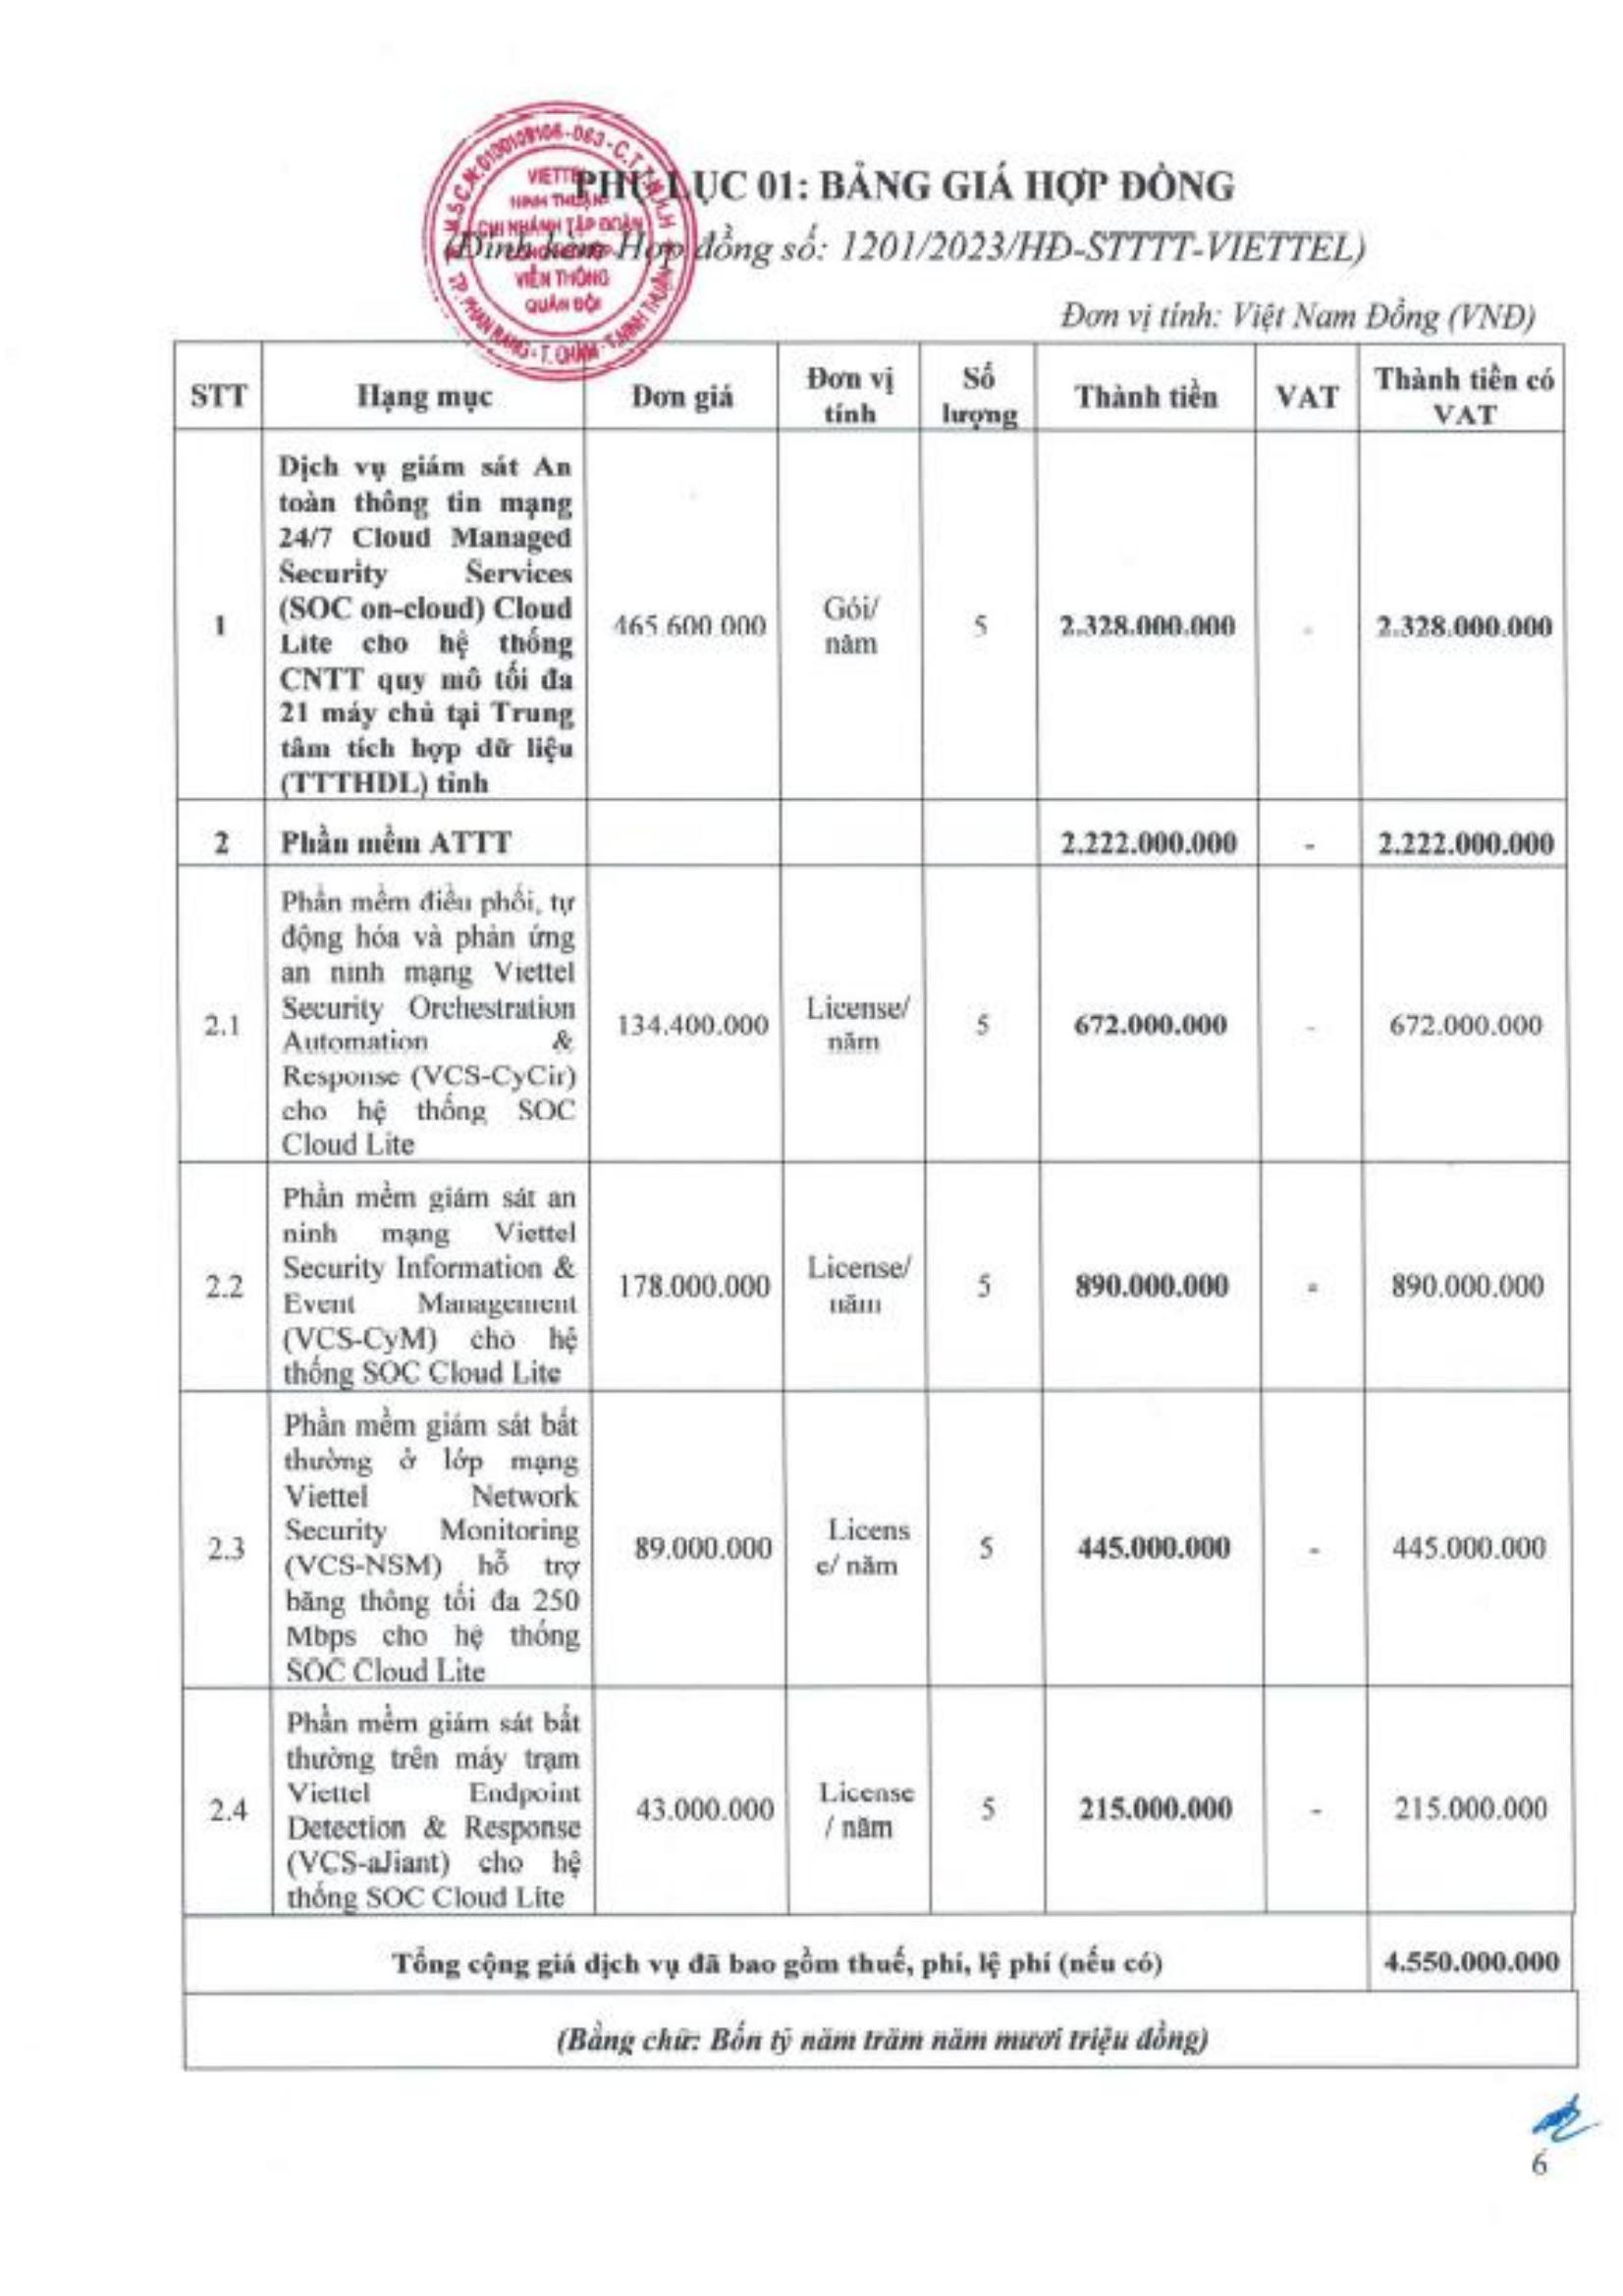

In [7]:
image

In [ ]:
image_path = "/raid/phundh/document_scan_ocr/images/page_1.jpg"  # Thay bằng đường dẫn của file ảnh
#2. If the image contains tables, extract all tabular data into a structured **JSON format**.  Clearly label and organize the table's headers, rows, and data values in the JSON.
# Mở ảnh từ file
#5. just extract the information from the image. Paragraph enclosed in parentheses by the tag pair <ptext> </ptext>. Table (if exist) enclosed in parentheses by the tag pair <board> </board>.
image = Image.open(image_path)

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": 
        """Act as an OCR assistant and table extractor. Extract information with this step:
1. Please provide output with this instruction: Do not provide any additional explanations
2. Recognize all visible text in the image **accurately** in Vietnamese.
3. Correct spelling mistakes or words you think don't make sense if necessary.
4. If the image contains paragraphs, extract all this with format plain text and enclosed in parentheses by the tag pair <ptext> </ptext>.
5. If the image contains tables, extract all tabular data into a structured **JSON format** and enclosed all information extracted in parentheses by the tag pair <board> </board>. If table is not exist, please don't generate <board> and </board> (Avoid information distortion and redundancy).
"""}
    ]}
]
input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt"
).to(model.device)

output = model.generate(**inputs, max_new_tokens=2000, top_k = 3)
print(processor.decode(output[0]))

In [5]:
bm_pics = ['72.jpg',
'90.jpg',
'z3250010112099_a53274d778eab64d7f72e9b3afc43180.jpg',
'z3250968174948_440d4491b3bf34f10ead7e7e8f91bdce.jpg',
'z3276681182415_90b9409f7868df75fe4e173d645731a8.jpg',
'z3295945989909_444ae17c31a6c50be4ac7f1fd2280fab.jpg',
'z3295989097616_cb220d47c39e066281ffb655f6068232.jpg',
'z3296008231939_22c8bef16f5e35d5a151a75bacb1f9c5.jpg',
'z3299117861620_c1e2349dfe0da2f24158dfa126b92d0f.jpg',
'z3296010217485_8cfe881e153a71015b26333f1045be33 (1).jpg',
'z3295967844623_60e2f2e91bc308a008ea6d21b2f11d9d.jpg']

In [21]:
# image_path = "/raid/phundh/document_scan_ocr/images/page_1.jpg"  # Thay bằng đường dẫn của file ảnh
#2. If the image contains tables, extract all tabular data into a structured **JSON format**.  Clearly label and organize the table's headers, rows, and data values in the JSON.
# Mở ảnh từ file
#5. just extract the information from the image. Paragraph enclosed in parentheses by the tag pair <ptext> </ptext>. Table (if exist) enclosed in parentheses by the tag pair <board> </board>.
image_path = '/raid/phuongdtt/ocr_ral_v2/data/Đơn hàng OCR - P.BH1/Vùng 1/z3296008231939_22c8bef16f5e35d5a151a75bacb1f9c5.jpg'
image = Image.open(image_path)

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": 
        """Act as an OCR assistant and table extractor. Extract information with this step:
1. Please provide output with this instruction: Do not provide any additional explanations
2. Recognize all visible text in the image **accurately** in Vietnamese.
3. Correct spelling mistakes or words you think don't make sense if necessary.
4. Only provide output for tables, do not provide any additional information that is not in the tables

Provide the output as follows:
 **JSON structure** for tables with clear field names and data rows. Provide the output for tables as the format below. **If any field is not available in the document, leave the field blank**
 My format I want you provide: {
  "Yêu cầu đặt hàng": [
    {
      "STT": "string",
      "Tên sản phẩm (Tên hàng)": "string" [Example: Bóng LED 20W, Ấm siêu tốc],
      "Đơn vị tính (DVT)": "string" [Example: cái, thùng] ("" if the field does not exist) 
       "Số lượng (SL)": "integer" [Example: 1, 14, 20] ("" if the field does not exist) 
      "Đơn giá" : "string" ("" if athe field does not exist) 
      "Thành tiền": "string" ("" if athe field does not exist) 
    }
  ]
}
**If information of any field does not exists in the document, the value for that field should be ""**
**Do not add any additional comments or interpretations.**
"""}
    ]}
]
input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt"
).to(model.device)

output = model.generate(**inputs, max_new_tokens=5000, top_k = 3)
print(processor.decode(output[0]))

<|begin_of_text|><|start_header_id|>user<|end_header_id|>

<|image|>Act as an OCR assistant and table extractor. Extract information with this step:
1. Please provide output with this instruction: Do not provide any additional explanations
2. Recognize all visible text in the image **accurately** in Vietnamese.
3. Correct spelling mistakes or words you think don't make sense if necessary.
4. Only provide output for tables, do not provide any additional information that is not in the tables

Provide the output as follows:
 **JSON structure** for tables with clear field names and data rows. Provide the output for tables as the format below. **If any field is not available in the document, leave the field blank**
 My format I want you provide: {
  "Yêu cầu đặt hàng": [
    {
      "STT": "string",
      "Tên sản phẩm (Tên hàng)": "string" [Example: Bóng LED 20W, Ấm siêu tốc],
      "Đơn vị tính (DVT)": "string" [Example: cái, thùng] ("" if the field does not exist) 
       "Số lượng (SL)"

/raid/phuongdtt/ocr_ral_v2/data/Đơn hàng OCR - P.BH1/Vùng 1/z3296008231939_22c8bef16f5e35d5a151a75bacb1f9c5.jpg


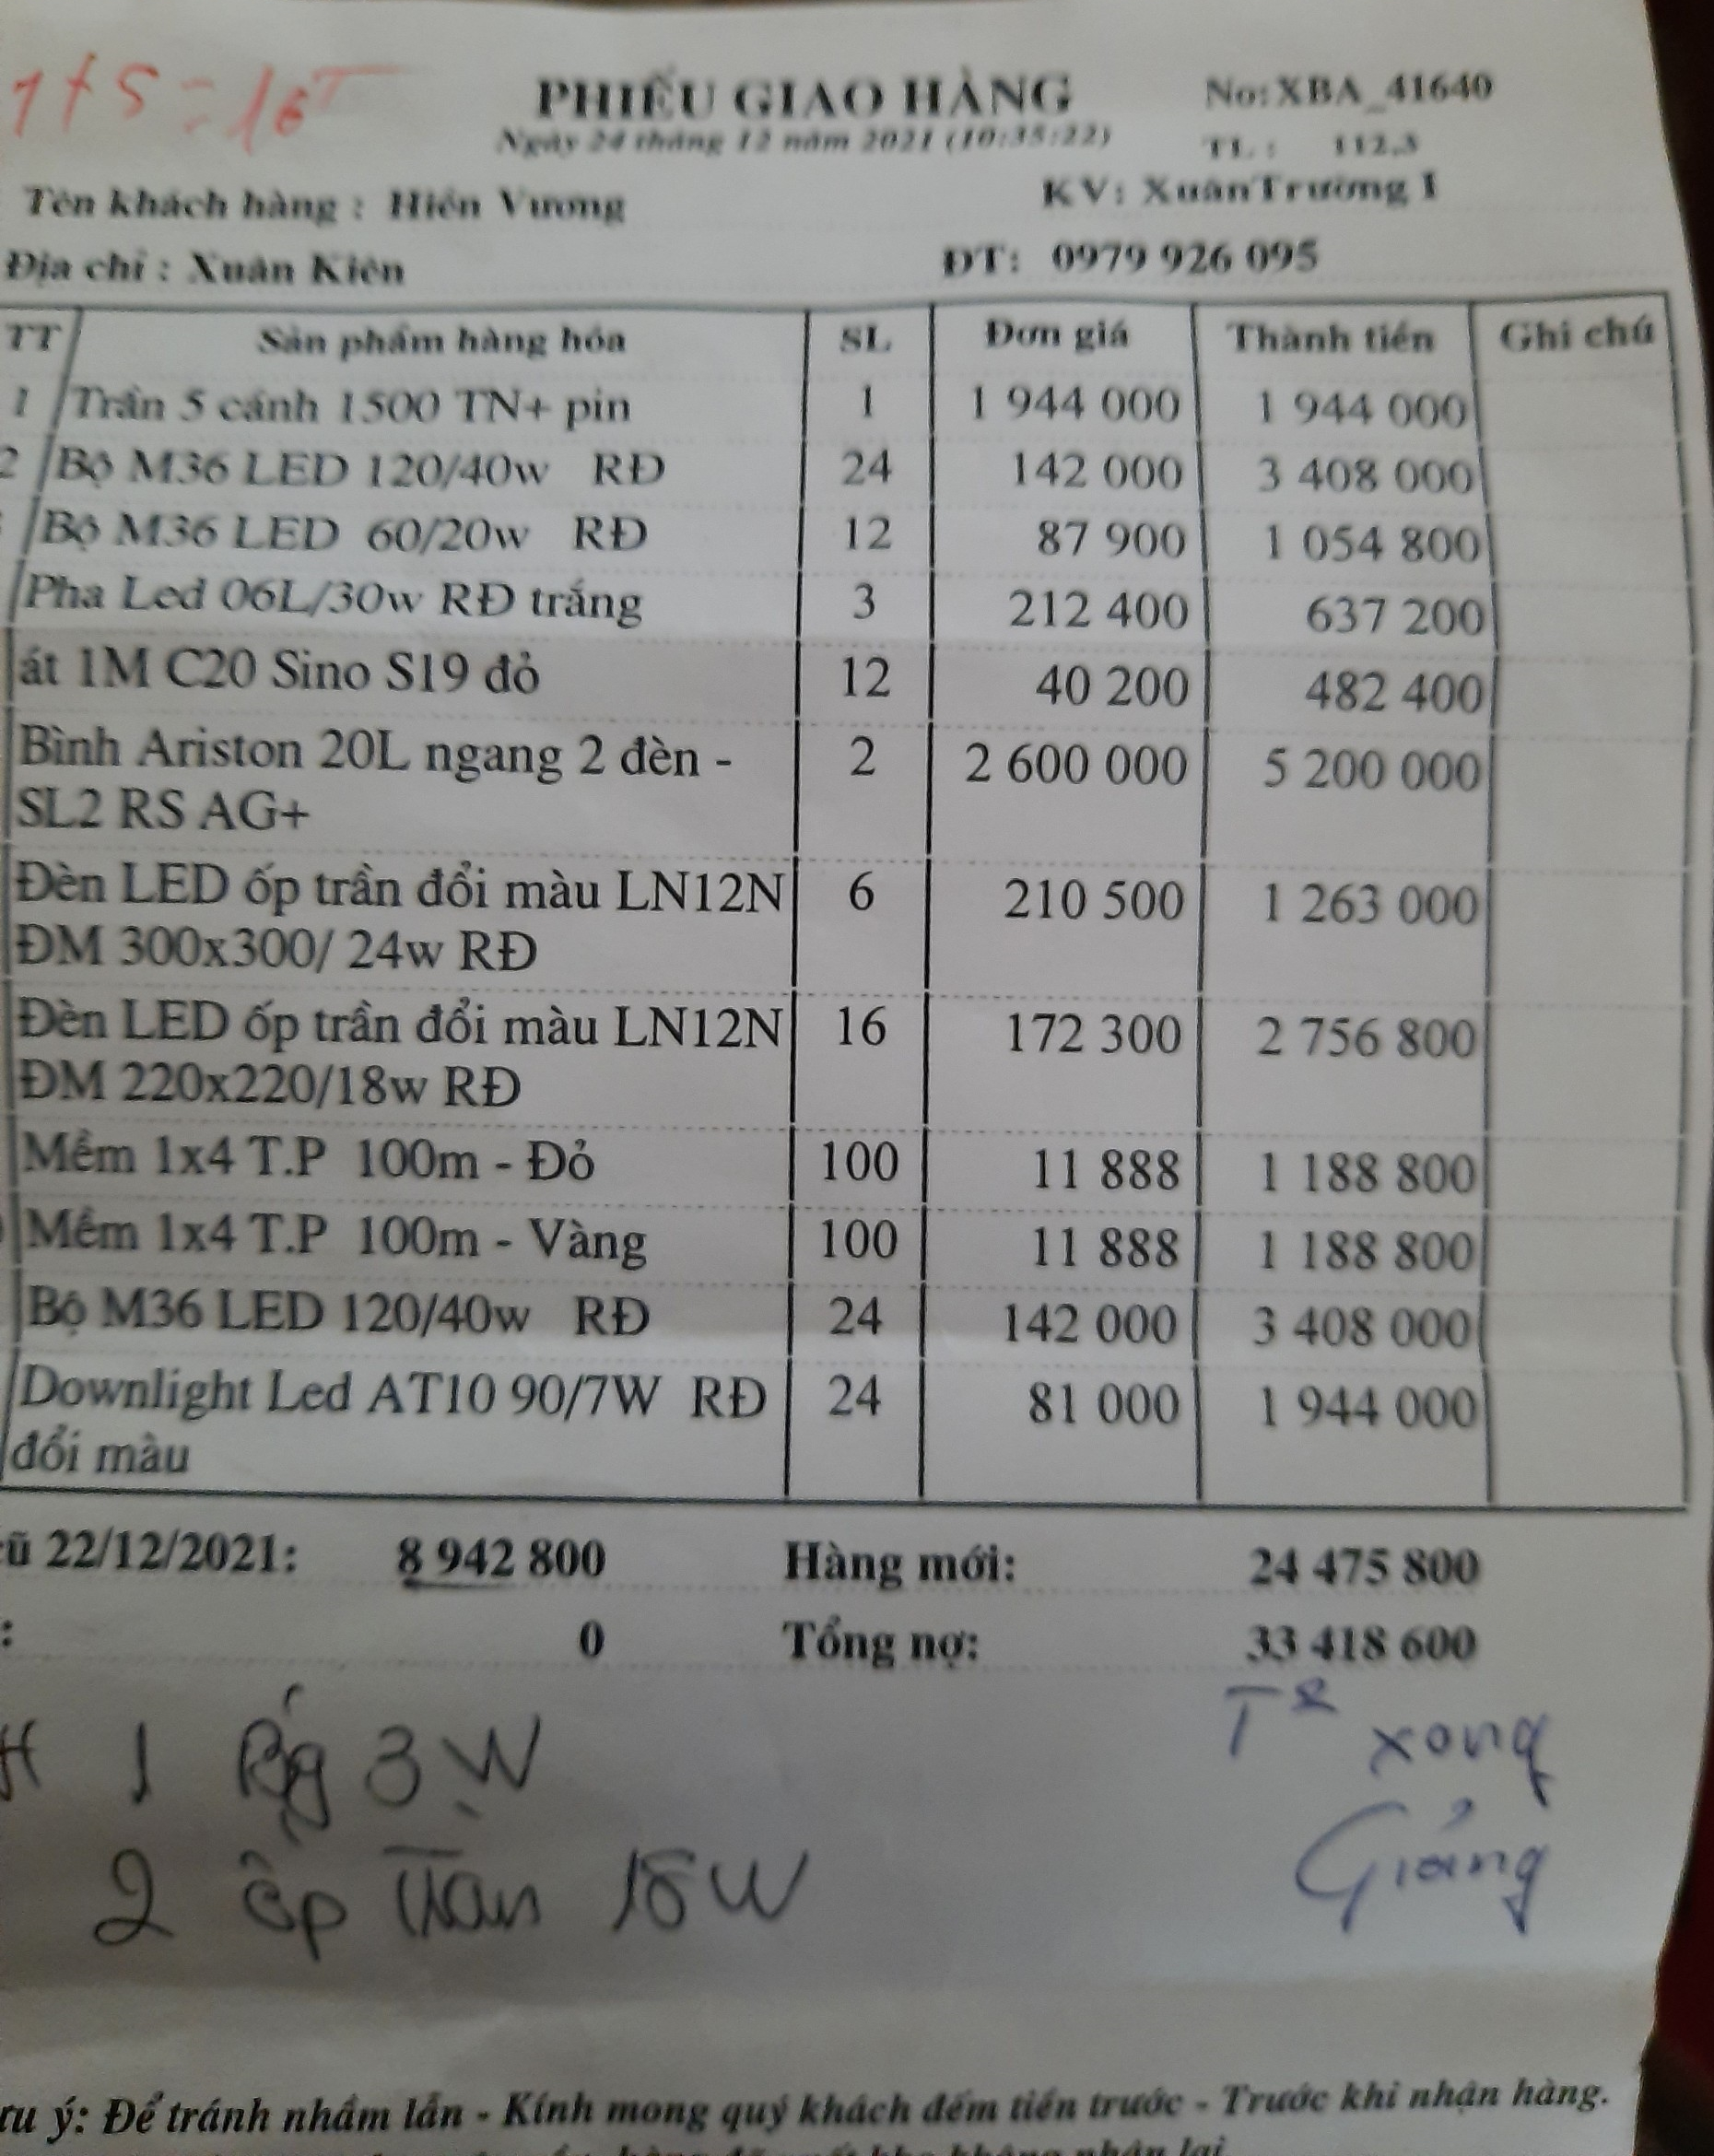

In [22]:
print(image_path)
Image.open(image_path)